In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from autoslo.utils.colors import Palette
from matplotlib.lines import Line2D


In [3]:
path = '/home/markakis/chunkbench/data/__workloads/ext_tpcds1000/redbench_provisioned_157_0.parquet'
df = pd.read_parquet(path)
print(df.shape)
df.head()

(100715, 4)


,query_id,query_text_id,repetition_id,abs_start_time
0,144818,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 00:07:53.848406
1,135371,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 00:09:48.752556
2,164335,ext_tpcds1000#009#001,2119f3f23aa50fd3e121fdb626a2f99b788222365474d1...,2024-03-01 01:17:28.891218
3,158039,ext_tpcds1000#028#003,2372d839f38889e977cfe9b8b1449d962b081fdf2354d7...,2024-03-01 01:25:17.120122
4,152937,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 01:42:08.389187


In [47]:
def add_columns(df):

    df['template_id'] = df['query_text_id'].apply(lambda x: x.split('#')[1])
    df['query_num_within_template'] = df['query_text_id'].apply(lambda x: int(x.split('#')[2]))
    df['obs_date'] = df['abs_start_time'].dt.date
    df['day_of_week'] = df['abs_start_time'].dt.dayofweek
    df['hour'] = df['abs_start_time'].dt.hour
    df['timestamp_within_hour'] = df['abs_start_time'].dt.minute * 60 + df['abs_start_time'].dt.second
add_columns(df)
df.head()

,query_id,query_text_id,repetition_id,abs_start_time,template_id,query_num_within_template,date,day_of_week,hour,obs_date,timestamp_within_hour
0,144818,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 00:07:53.848406,028,1,2024-03-01,4,0,2024-03-01,473
1,135371,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 00:09:48.752556,028,1,2024-03-01,4,0,2024-03-01,588
2,164335,ext_tpcds1000#009#001,2119f3f23aa50fd3e121fdb626a2f99b788222365474d1...,2024-03-01 01:17:28.891218,009,1,2024-03-01,4,1,2024-03-01,1048
3,158039,ext_tpcds1000#028#003,2372d839f38889e977cfe9b8b1449d962b081fdf2354d7...,2024-03-01 01:25:17.120122,028,3,2024-03-01,4,1,2024-03-01,1517
4,152937,ext_tpcds1000#028#001,4885fdc3dff5a1811ca7836356c2de999ce9bd3033af1f...,2024-03-01 01:42:08.389187,028,1,2024-03-01,4,1,2024-03-01,2528


In [22]:
target_day = pd.to_datetime('2024-05-27')
target_df = df[df['date'] == target_day.date()]
target_df.shape

(1392, 9)

In [146]:
def plot(experiment):

    sampled_workloads_dir = f"/home/markakis/chunkbench/data/tuner_runs/history_exp/{experiment}/sampled_workloads"
    sampled_workloads = {}

    all_template_ids = sorted(target_df["template_id"].unique())

    for split in ["train", "val"]:
        subdir = f"{sampled_workloads_dir}/{split}"
        for filename in os.listdir(subdir):
            if filename.endswith(".parquet"):
                path = f"{subdir}/{filename}"
                sampled_df = pd.read_parquet(path)
                add_columns(sampled_df)
                all_template_ids = sorted(
                    set(all_template_ids)
                    | set(sampled_df["template_id"].unique())
                )
                sampled_workloads[f'{filename.split(".")[0]}'] = sampled_df

    fig, axs = plt.subplots(1, 2, figsize=(20, 6))

    true_color = Palette.dark_red
    sampled_train_color = Palette.light_gray
    sampled_val_color = Palette.gray

    # Plot a distribution of query counts over templates.
    ax = axs[0]
    x_tick_positions = range(len(all_template_ids))
    x_tick_labels = all_template_ids

    for workload_name, sampled_df in sampled_workloads.items():
        sampled_template_counts = sampled_df['template_id'].value_counts().reindex(all_template_ids, fill_value=0)
        if workload_name.startswith('t'):
            color = sampled_train_color
        else:
            color = sampled_val_color
        ax.scatter(x_tick_positions, sampled_template_counts, marker='o',  color=color, alpha = 0.5)

    template_counts = (
        target_df["template_id"]
        .value_counts()
        .reindex(all_template_ids, fill_value=0)
    )
    ax.scatter(
        x_tick_positions,
        template_counts,
        marker="o",
        color=true_color,
        alpha=0.5,
    )

    ax.set_xticks(x_tick_positions)
    ax.set_xticklabels(x_tick_labels, rotation=90)
    ax.set_xlabel("Template ID")
    ax.set_ylabel("Count")
    ax.set_title(f"Query Counts by Template")
    ax.set_yscale("log")

    legend_elements = [
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Target Day",
            markerfacecolor=true_color,
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Sampled Training Workloads",
            markerfacecolor=sampled_train_color,
            markersize=10,
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            label="Sampled Validation Workloads",
            markerfacecolor=sampled_val_color,
            markersize=10,
        ),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    # Plot a distribution of query counts over hour of day.
    ax = axs[1]

    for workload_name, sampled_df in sampled_workloads.items():
        sampled_hour_counts = (
            sampled_df["hour"].value_counts().reindex(range(24), fill_value=0)
        )
        if workload_name.startswith("t"):
            color = sampled_train_color
        else:
            color = sampled_val_color
        ax.plot(
            sampled_hour_counts.index,
            sampled_hour_counts,
            marker="o",
            color=color,
            alpha=0.5,
        )

    hour_counts = (
        target_df["hour"].value_counts().reindex(range(24), fill_value=0)
    )
    ax.plot(
        hour_counts.index, hour_counts, marker="o", color=true_color, alpha=0.5
    )

    ax.set_xticks(range(24))
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Count")
    ax.set_title(f"Query Counts by Hour of Day")

    ax.legend(handles=legend_elements, loc="upper left")

    plt.suptitle("Experiment: " + experiment)

    plt.tight_layout()
    plt.show()

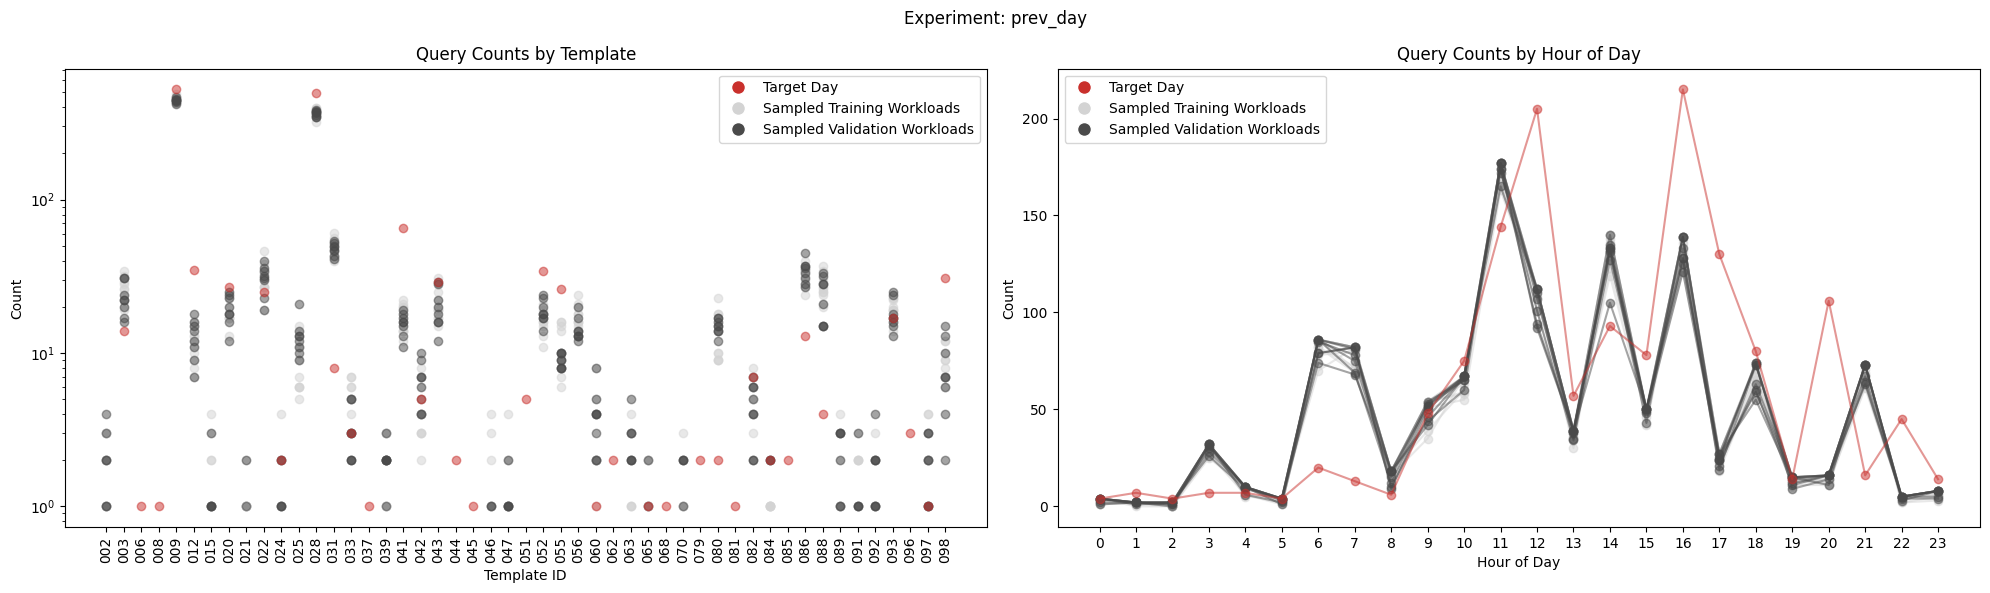

In [147]:
plot('prev_day')

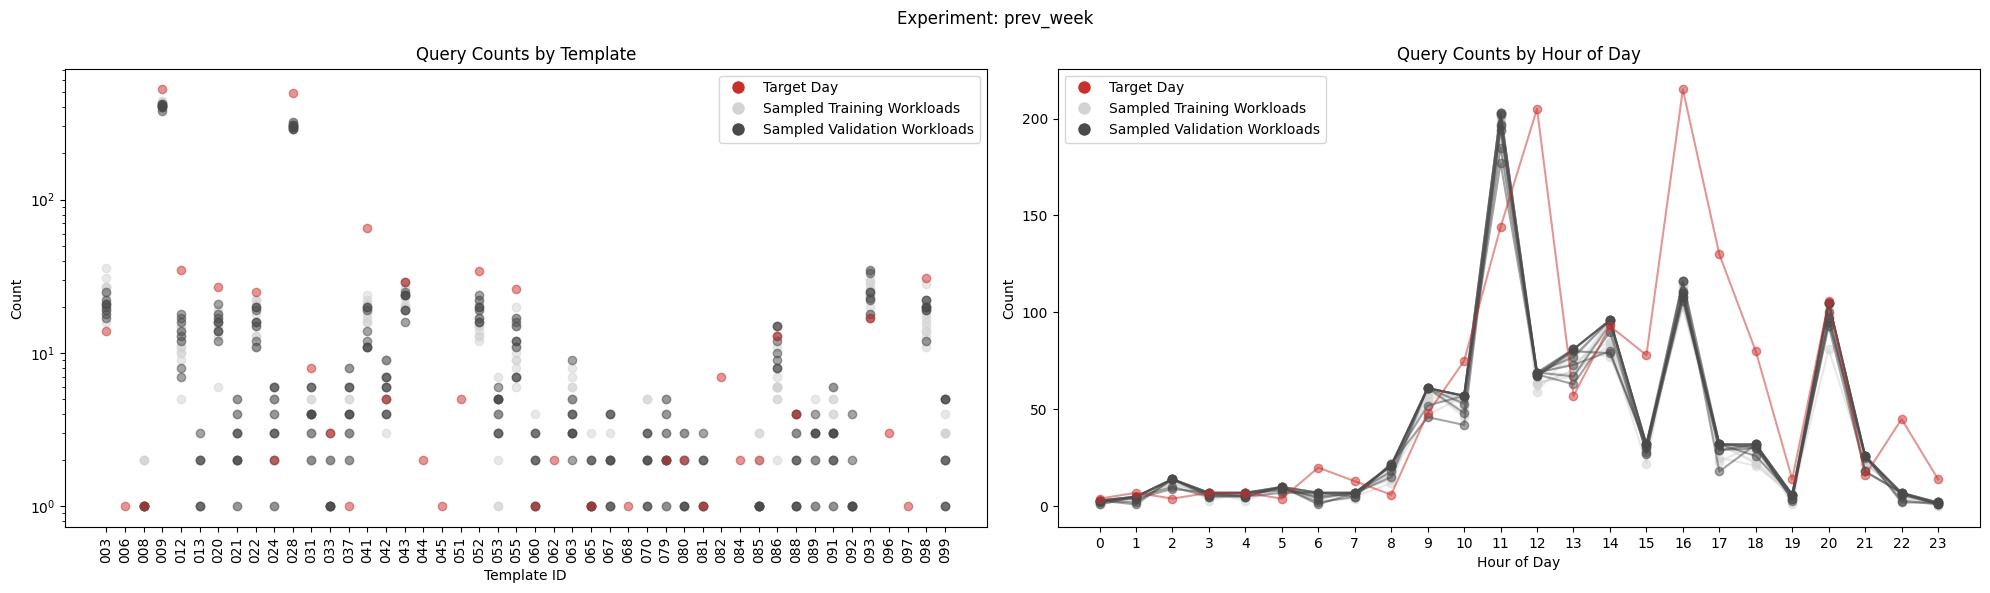

In [119]:
plot('prev_week')

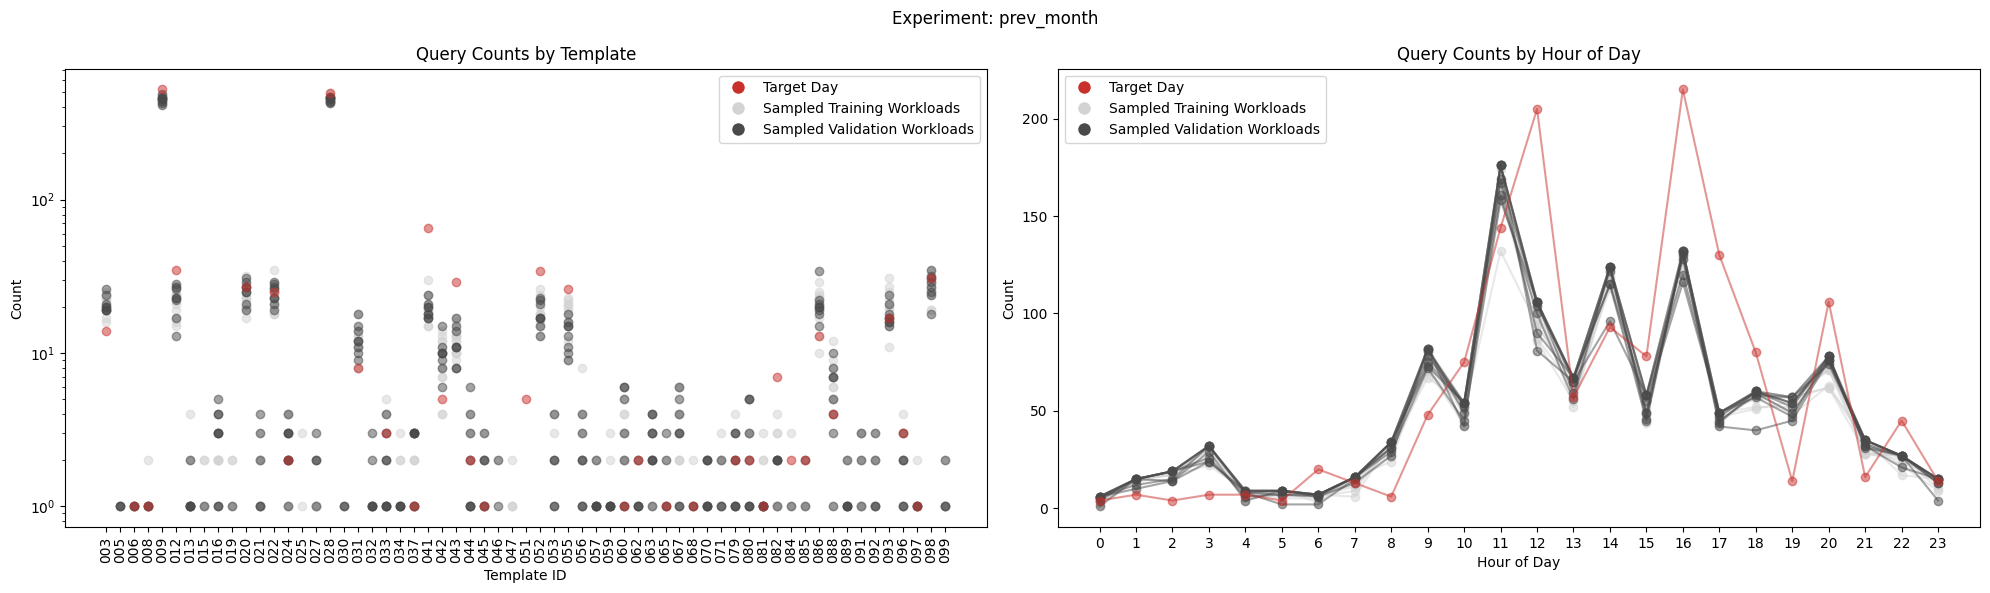

In [120]:
plot('prev_month')

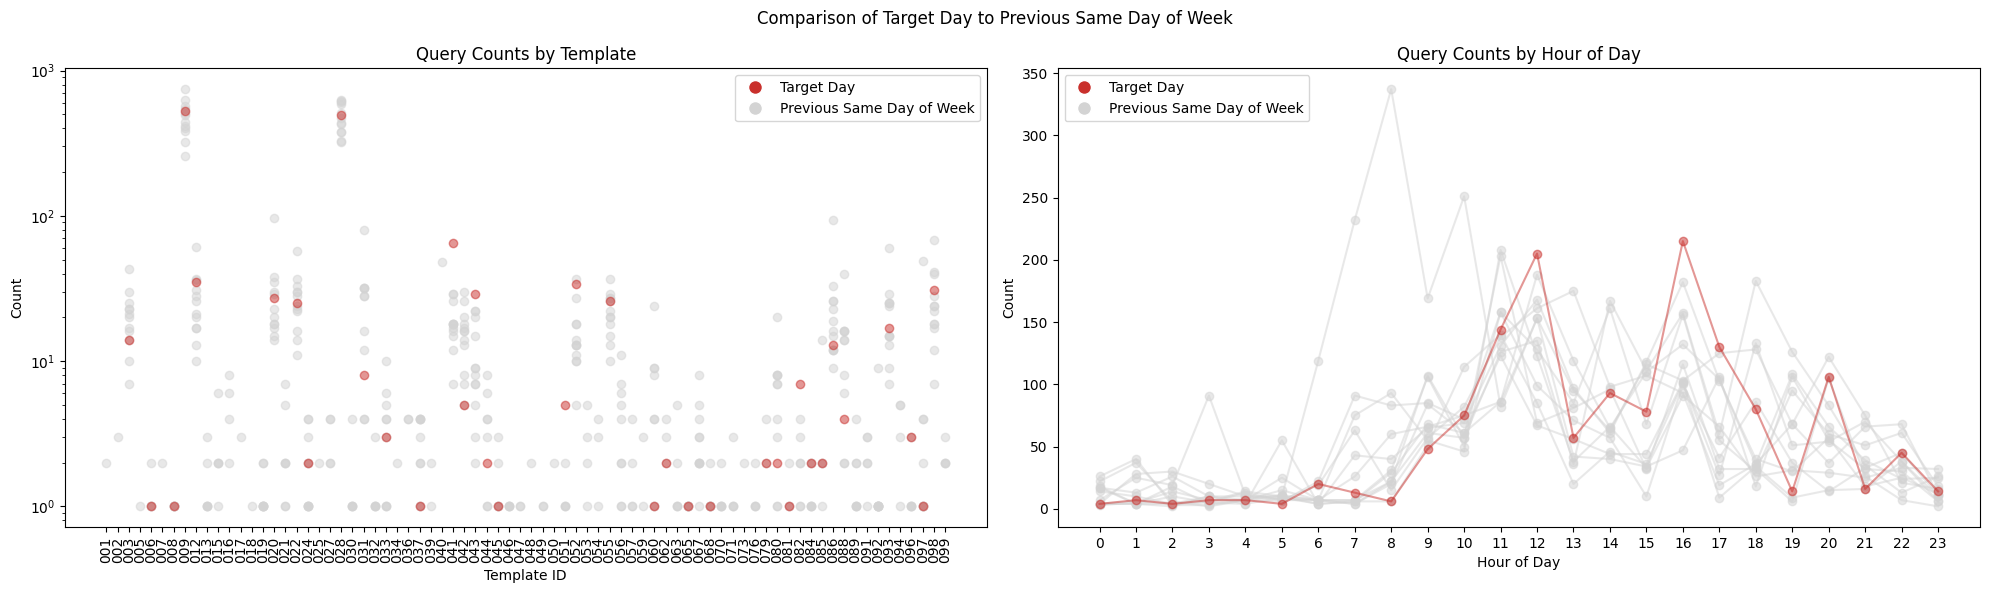

In [130]:
# Plot an equivalent plot, but using all days of the df that are the same day of week as the target day.


target_day_of_week = target_day.dayofweek
all_same_dow_df = df[df['day_of_week'] == target_day_of_week]

all_template_ids = sorted(all_same_dow_df['template_id'].unique())


fig, axs = plt.subplots(1 ,2, figsize=(20, 6))

true_color = Palette.dark_red
sampled_train_color = Palette.light_gray


# Plot a distribution of query counts over templates.
ax = axs[0]
x_tick_positions = range(len(all_template_ids))
x_tick_labels = all_template_ids

for date, sub_df in all_same_dow_df.groupby('date'):
    if date == target_day.date():
        continue
    sampled_template_counts = sub_df['template_id'].value_counts().reindex(all_template_ids, fill_value=0)
    color = sampled_train_color
    ax.scatter(x_tick_positions, sampled_template_counts, marker='o',  color=color, alpha = 0.5)

template_counts = target_df['template_id'].value_counts().reindex(all_template_ids, fill_value=0)
ax.scatter(x_tick_positions, template_counts, marker = 'o',  color=true_color, alpha=0.5)

ax.set_xticks(x_tick_positions)
ax.set_xticklabels(x_tick_labels, rotation=90)
ax.set_xlabel('Template ID')
ax.set_ylabel('Count')
ax.set_title(f'Query Counts by Template')
ax.set_yscale('log')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Target Day', markerfacecolor=true_color, markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Previous Same Day of Week', markerfacecolor=sampled_train_color, markersize=10),
]
ax.legend(handles=legend_elements, loc='upper right')

# Plot a distribution of query counts over hour of day.
ax = axs[1]

for date, sub_df in all_same_dow_df.groupby('date'):
    if date == target_day.date():
        continue
    sampled_hour_counts = sub_df['hour'].value_counts().reindex(range(24), fill_value=0)
    color = sampled_train_color
    ax.plot(sampled_hour_counts.index, sampled_hour_counts, marker='o', color=color, alpha=0.5)

hour_counts = target_df['hour'].value_counts().reindex(range(24), fill_value=0)
ax.plot(hour_counts.index, hour_counts, marker='o', color=true_color, alpha=0.5)

ax.set_xticks(range(24))
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Count')
ax.set_title(f'Query Counts by Hour of Day')

ax.legend(handles=legend_elements, loc='upper left')

plt.suptitle('Comparison of Target Day to Previous Same Day of Week')

plt.tight_layout()
plt.show()

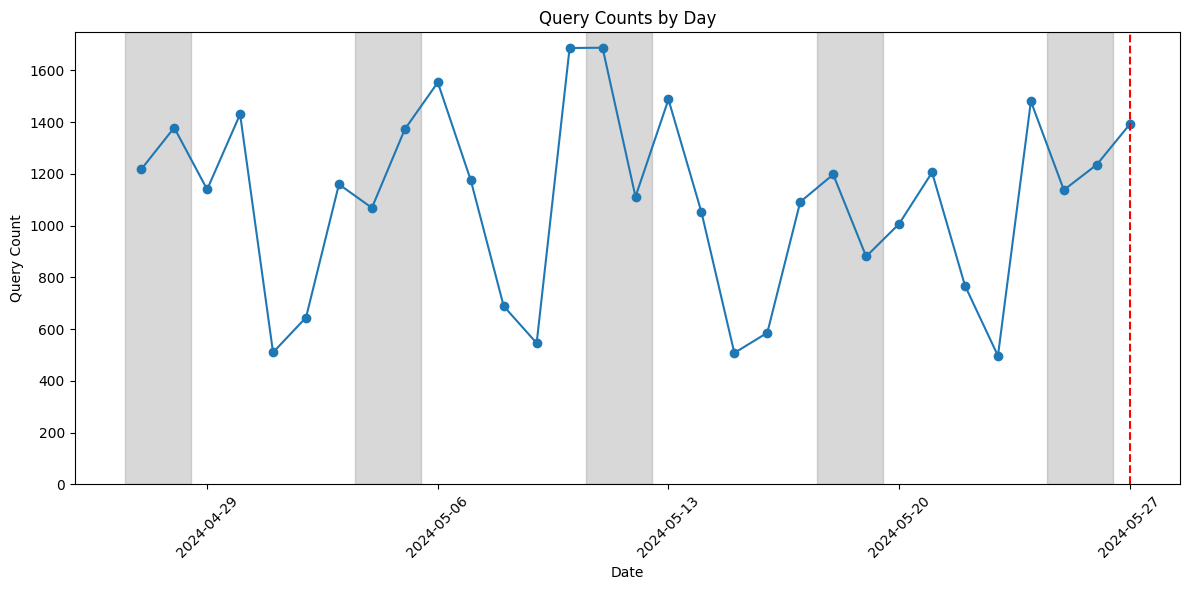

In [137]:
# Plot the count of queries per day, starting one month before the target date
query_counts_by_day = df.groupby("date").size()
query_counts_by_day = query_counts_by_day[
    (query_counts_by_day.index >= (target_day - pd.Timedelta(days=30)).date())
    & (query_counts_by_day.index <= target_day.date())
]

plt.figure(figsize=(12, 6))
plt.plot(query_counts_by_day.index, query_counts_by_day.values, marker="o")
plt.axvline(
    x=target_day.date(), color="red", linestyle="--", label="Target Day"
)

# Shade over every weekend
for date in query_counts_by_day.index:
    if pd.to_datetime(date).dayofweek == 5:  # Saturday=5, Sunday=6
        plt.axvspan(
            pd.to_datetime(date) - pd.Timedelta(days=0.5),
            pd.to_datetime(date) + pd.Timedelta(days=1.5),
            color="gray",
            alpha=0.3,
        )

plt.xlabel("Date")
plt.ylabel("Query Count")
plt.title("Query Counts by Day")
plt.ylim(bottom=0)

# Only have x ticks for mondays
plt.xticks(
    [date for date in query_counts_by_day.index if pd.to_datetime(date).dayofweek == 0]
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()